Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
R2 Score: 0.9915193013796656
MAE: 0.6375913577958011
MSE: 1.1489868991146805
RMSE: 1.0719080646747092


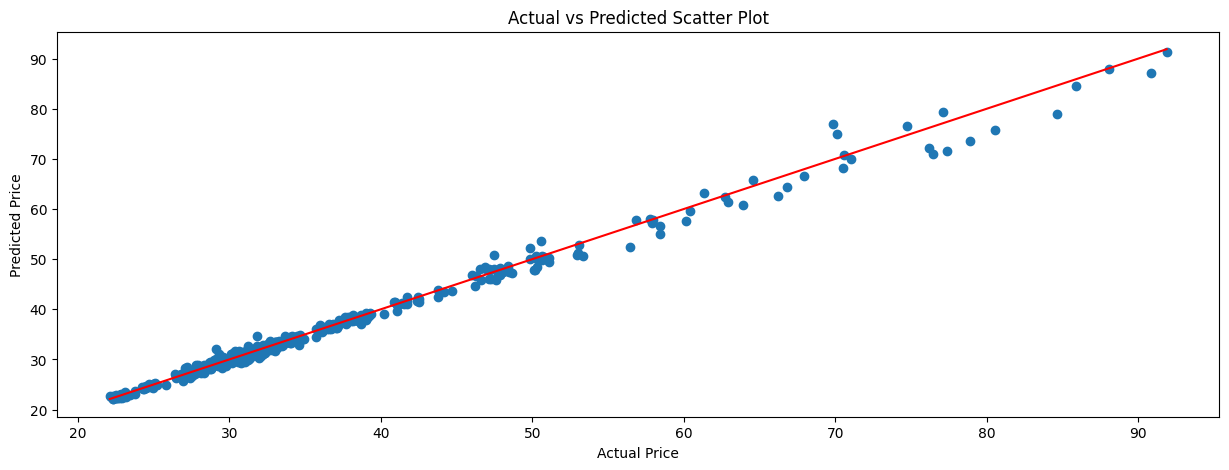

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("../../Data/CSV/silver_prices_10years.csv")

print(data.isnull().sum())

data['Target'] = data['Close'].shift(-1)

data = data.dropna()

features = ['Open', 'High', 'Low']
X = data[features]
y = data['Target']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, shuffle=False)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

plt.figure(figsize=(15,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Scatter Plot")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()